In [1]:
import pandas as pd;
import numpy as np;
import matplotlib.pyplot as plt;
import seaborn as sns;

In [2]:
df = pd.read_csv("employee_burnout_analysis_dataset.csv");

In [4]:
df.head(11)

,employee_id,employee_name,department,working_hours_per_day,sleep_hours,stress_level,meetings_per_day,work_mode,productivity_score,salary,leaves_taken,burnout_risk
0,EMP1584,Albert Lopez,Marketing,5.2,5.6,10,4,Onsite,56,249127.0,17,Medium
1,EMP2215,Nicole Young,Sales,12.0,4.8,8,1,Hybrid,73,116462.0,22,High
2,EMP1877,Angela Edwards,Sales,9.3,4.9,6,2,Onsite,92,140851.0,28,Medium
3,EMP5230,Heidi Padilla,it,8.5,5.4,9,2,Remote,46,226467.0,22,Low
4,EMP5159,Charles Porter,HR,8.8,4.1,8,6,Hybrid,74,134054.0,2,Low
5,EMP5546,Gabrielle Gilbert,IT,7.1,6.4,9,1,Remote,81,147513.0,1,Low
6,EMP3787,George Munoz,Support,12.1,7.8,7,4,Onsite,70,170752.0,13,High
7,EMP2744,NaN,Operations,12.1,8.0,4,5,Remote,93,105172.0,3,High
8,EMP5481,Joseph Bailey,Finance,5.1,7.5,8,6,Remote,65,90133.0,23,High
9,EMP4801,Casey Wilson,Marketing,11.9,8.7,3,1,Remote,55,44702.0,29,Low


In [8]:
df.shape

(5180, 12)

In [9]:
df.columns

Index(['employee_id', 'employee_name', 'department', 'working_hours_per_day',
       'sleep_hours', 'stress_level', 'meetings_per_day', 'work_mode',
       'productivity_score', 'salary', 'leaves_taken', 'burnout_risk'],
      dtype='str')

# Data Cleaning

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5180 entries, 0 to 5179
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   employee_id            5180 non-null   str    
 1   employee_name          4940 non-null   str    
 2   department             5054 non-null   str    
 3   working_hours_per_day  5057 non-null   str    
 4   sleep_hours            5057 non-null   float64
 5   stress_level           5180 non-null   str    
 6   meetings_per_day       5180 non-null   int64  
 7   work_mode              5180 non-null   str    
 8   productivity_score     5180 non-null   str    
 9   salary                 5056 non-null   str    
 10  leaves_taken           5180 non-null   int64  
 11  burnout_risk           5180 non-null   str    
dtypes: float64(1), int64(2), str(9)
memory usage: 485.8 KB


In [11]:
df.describe()

,sleep_hours,meetings_per_day,leaves_taken
count,5057.000000,5180.00000,5180.000000
mean,5.991418,5.97722,15.183977
std,1.732579,3.75385,8.950937
min,3.000000,0.00000,0.000000
25%,4.500000,3.00000,7.000000
50%,6.000000,6.00000,15.000000
75%,7.500000,9.00000,23.000000
max,9.000000,12.00000,30.000000


# Fix DataTypes

In [12]:
df["salary"]=pd.to_numeric(df["salary"],errors="coerce")

In [13]:
df["working_hours_per_day"] = pd.to_numeric(df["working_hours_per_day"],errors="coerce")

In [14]:
df["stress_level"] = pd.to_numeric(df["stress_level"],errors="coerce")

In [15]:
df["productivity_score"] = pd.to_numeric(df["productivity_score"],errors="coerce")

# Check Null Values

In [16]:
df.isnull().sum()

employee_id                0
employee_name            240
department               126
working_hours_per_day    148
sleep_hours              123
stress_level              25
meetings_per_day           0
work_mode                  0
productivity_score        25
salary                   149
leaves_taken               0
burnout_risk               0
dtype: int64

# Handle Null Values

In [17]:
df["salary"]=df["salary"].fillna(df["salary"].median());

In [18]:
df["salary"].isnull().sum()

np.int64(0)

In [19]:
df["salary"].head(64)

0     249127.0
1     116462.0
2     140851.0
3     226467.0
4     134054.0
        ...   
59     84816.0
60    240891.0
61     40993.0
62    127436.0
63    137643.0
Name: salary, Length: 64, dtype: float64

In [20]:
df["working_hours_per_day"] = df["working_hours_per_day"].fillna(df["working_hours_per_day"].median())

In [21]:
df["working_hours_per_day"].isnull().sum()

np.int64(0)

In [22]:
df["working_hours_per_day"].head(173)

0       5.2
1      12.0
2       9.3
3       8.5
4       8.8
       ... 
168     7.6
169    14.0
170     9.5
171    10.3
172    10.7
Name: working_hours_per_day, Length: 173, dtype: float64

In [23]:
df["sleep_hours"].isnull().sum()

np.int64(123)

In [24]:
df["sleep_hours"] = df["sleep_hours"].fillna(df["sleep_hours"].median())

In [25]:
df["sleep_hours"].isnull().sum()

np.int64(0)

In [26]:
df["sleep_hours"].head(46)

0     5.6
1     4.8
2     4.9
3     5.4
4     4.1
5     6.4
6     7.8
7     8.0
8     7.5
9     8.7
10    4.7
11    4.0
12    5.3
13    7.3
14    4.4
15    3.2
16    7.7
17    7.7
18    4.0
19    5.4
20    7.6
21    8.2
22    4.6
23    4.0
24    3.4
25    9.0
26    4.4
27    5.8
28    6.2
29    7.6
30    7.9
31    6.7
32    6.7
33    4.3
34    8.8
35    8.6
36    8.8
37    6.8
38    6.9
39    8.1
40    6.8
41    3.3
42    7.6
43    4.7
44    6.0
45    6.8
Name: sleep_hours, dtype: float64

In [27]:
df["employee_name"].isnull().sum()

np.int64(240)

In [28]:
df["employee_name"]=df["employee_name"].fillna("unknown Employee")

In [29]:
df["employee_name"].isnull().sum()

np.int64(0)

In [30]:
df["employee_name"].head(10)

0         Albert Lopez
1         Nicole Young
2       Angela Edwards
3        Heidi Padilla
4       Charles Porter
5    Gabrielle Gilbert
6         George Munoz
7     unknown Employee
8        Joseph Bailey
9         Casey Wilson
Name: employee_name, dtype: str

In [31]:
df["department"].isnull().sum()

np.int64(126)

In [32]:
df["department"]=df["department"].fillna("unknown")

In [33]:
df["department"].isnull().sum()

np.int64(0)

In [34]:
df["department"].head(96)

0     Marketing
1         Sales
2         Sales
3            it
4            HR
        ...    
91      Support
92    Marketing
93           IT
94           IT
95      unknown
Name: department, Length: 96, dtype: str

In [35]:
df.isnull().sum()

employee_id               0
employee_name             0
department                0
working_hours_per_day     0
sleep_hours               0
stress_level             25
meetings_per_day          0
work_mode                 0
productivity_score       25
salary                    0
leaves_taken              0
burnout_risk              0
dtype: int64

In [36]:
df["stress_level"].dtype

dtype('float64')

In [37]:
df["stress_level"]=pd.to_numeric(df["stress_level"],errors="coerce")

In [38]:
df["stress_level"]=df["stress_level"].fillna(df["stress_level"].median())

In [39]:
df["stress_level"].isnull().sum()

np.int64(0)

In [40]:
df.isnull().sum()

employee_id               0
employee_name             0
department                0
working_hours_per_day     0
sleep_hours               0
stress_level              0
meetings_per_day          0
work_mode                 0
productivity_score       25
salary                    0
leaves_taken              0
burnout_risk              0
dtype: int64

In [41]:
df["productivity_score"].dtype

dtype('float64')

In [42]:
df["productivity_score"]=df["productivity_score"].fillna(df["productivity_score"].median())

In [43]:
df["productivity_score"]=df["productivity_score"].astype(int)

In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5180 entries, 0 to 5179
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   employee_id            5180 non-null   str    
 1   employee_name          5180 non-null   str    
 2   department             5180 non-null   str    
 3   working_hours_per_day  5180 non-null   float64
 4   sleep_hours            5180 non-null   float64
 5   stress_level           5180 non-null   float64
 6   meetings_per_day       5180 non-null   int64  
 7   work_mode              5180 non-null   str    
 8   productivity_score     5180 non-null   int64  
 9   salary                 5180 non-null   float64
 10  leaves_taken           5180 non-null   int64  
 11  burnout_risk           5180 non-null   str    
dtypes: float64(4), int64(3), str(5)
memory usage: 485.8 KB


In [45]:
df.isnull().sum()

employee_id              0
employee_name            0
department               0
working_hours_per_day    0
sleep_hours              0
stress_level             0
meetings_per_day         0
work_mode                0
productivity_score       0
salary                   0
leaves_taken             0
burnout_risk             0
dtype: int64

# Remove Duplicate Values

In [46]:
df.duplicated().sum()

np.int64(159)

In [47]:
df=df.drop_duplicates()

In [48]:
df.shape

(5021, 12)

# Fix Standardize Text

In [49]:
df["work_mode"] = df["work_mode"].replace({"remote": "Remote","REMOTE": "Remote"})

In [50]:
df["department"] = df["department"].replace({"it": "IT"})

# Perform EDA (Exploratory Data Analysis)

In [51]:
df["department"].value_counts()

department
IT            777
HR            713
Sales         701
Support       701
Marketing     689
Finance       669
Operations    651
unknown       120
Name: count, dtype: int64

In [52]:
salary_percentage = (df.groupby("department")["salary"].sum() / df['salary'].sum())*100
salary_percentage = salary_percentage.round(2)
print(salary_percentage)

department
Finance       13.61
HR            14.50
IT            15.43
Marketing     13.64
Operations    12.82
Sales         14.06
Support       13.70
unknown        2.23
Name: salary, dtype: float64


In [53]:
df.groupby("department")["salary"].mean().round(2)

department
Finance       141064.29
HR            140980.86
IT            137683.55
Marketing     137227.64
Operations    136494.99
Sales         139072.46
Support       135476.36
unknown       128756.90
Name: salary, dtype: float64

In [54]:
df.groupby("work_mode")["productivity_score"].mean().round(2)

work_mode
Hybrid    70.36
Onsite    70.27
Remote    70.70
Name: productivity_score, dtype: float64

# Visualization

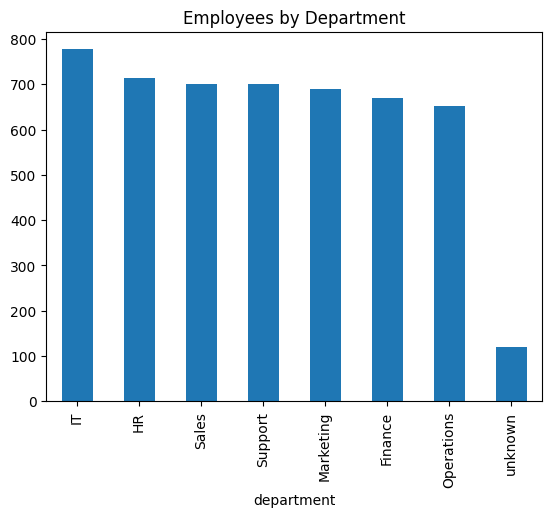

In [55]:
df["department"].value_counts().plot(
    kind="bar"
)

plt.title("Employees by Department")

plt.show()

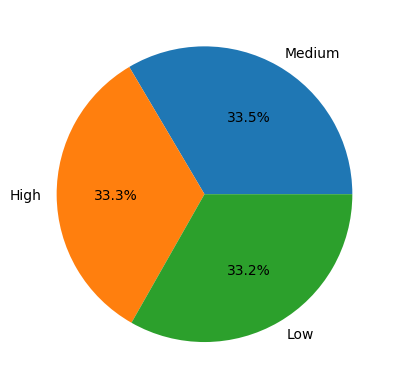

In [56]:
df["burnout_risk"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.show()

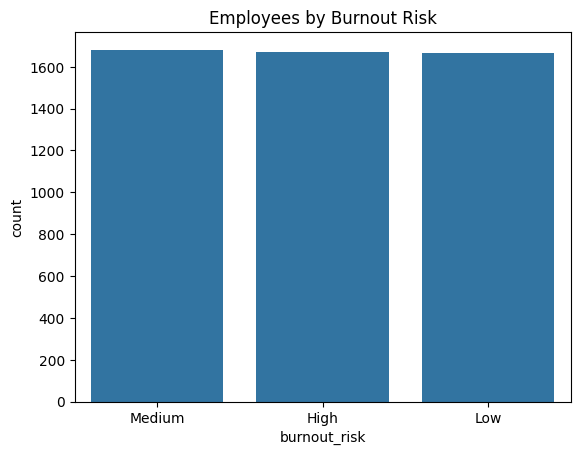

In [57]:
sns.countplot(x="burnout_risk", data=df)

plt.title("Employees by Burnout Risk")

plt.show()

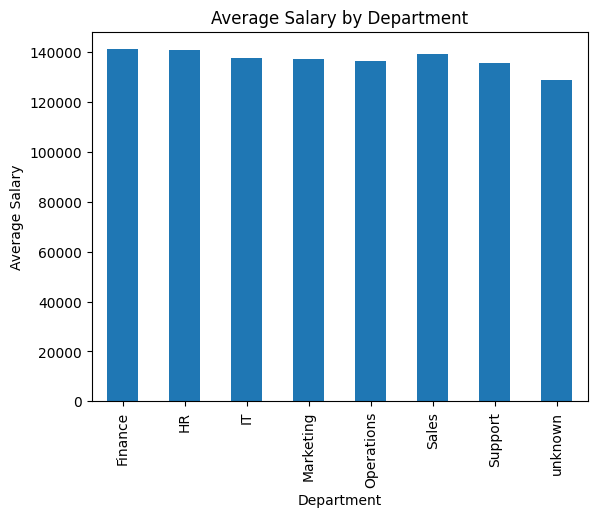

In [58]:
df.groupby("department")["salary"].mean().plot(
    kind="bar"
)

plt.title("Average Salary by Department")

plt.xlabel("Department")

plt.ylabel("Average Salary")

plt.show()

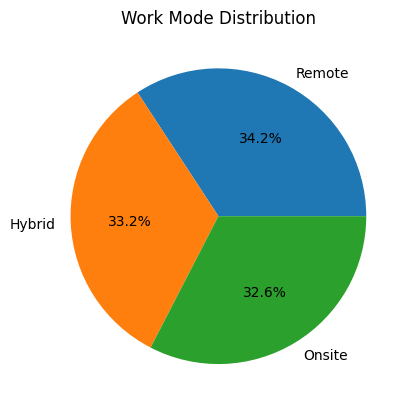

In [59]:
df["work_mode"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Work Mode Distribution")

plt.ylabel("")

plt.show()

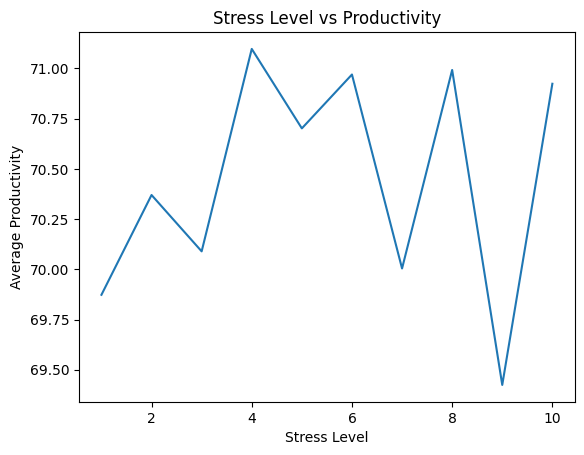

In [60]:
df.groupby("stress_level")[
    "productivity_score"
].mean().plot(kind="line")

plt.title("Stress Level vs Productivity")

plt.xlabel("Stress Level")

plt.ylabel("Average Productivity")

plt.show()

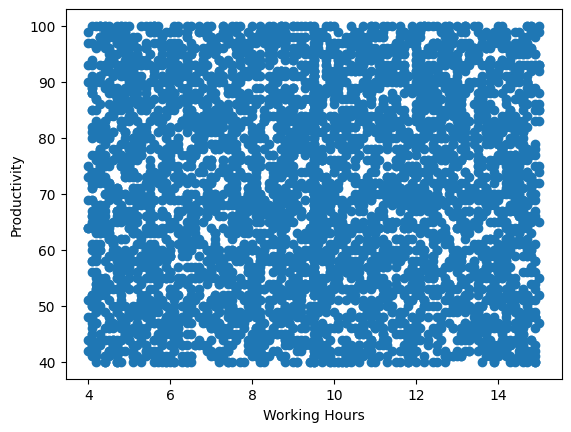

In [61]:
plt.scatter(
    df["working_hours_per_day"],
    df["productivity_score"]
)

plt.xlabel("Working Hours")

plt.ylabel("Productivity")

plt.show()

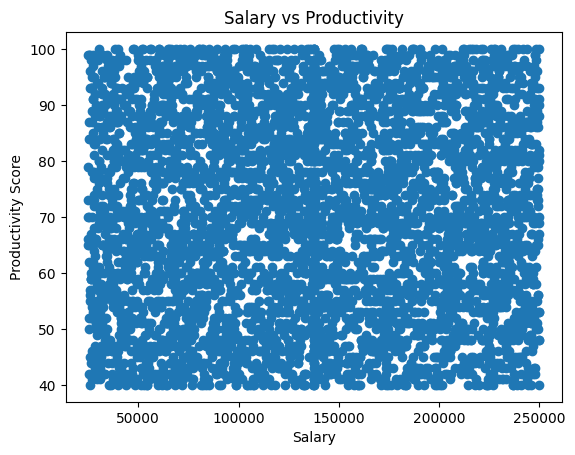

In [62]:
plt.scatter(
    df["salary"],
    df["productivity_score"]
)

plt.title("Salary vs Productivity")

plt.xlabel("Salary")

plt.ylabel("Productivity Score")

plt.show()

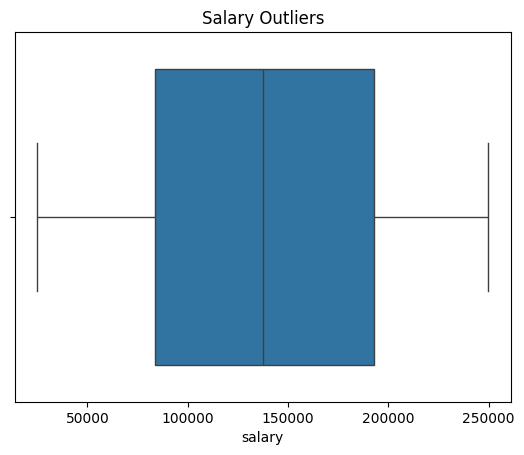

In [63]:
sns.boxplot(x=df["salary"])

plt.title("Salary Outliers")

plt.show()

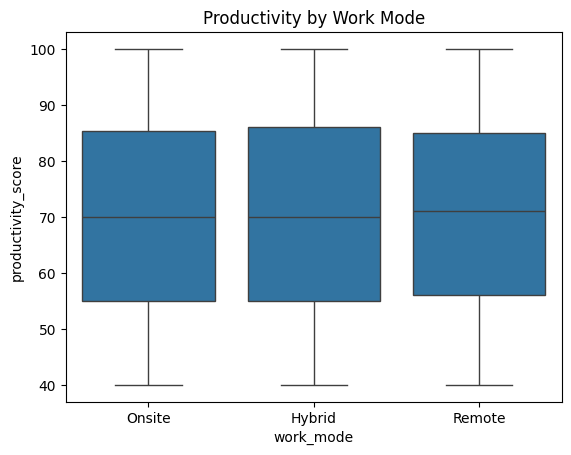

In [64]:
sns.boxplot(
    x="work_mode",
    y="productivity_score",
    data=df
)

plt.title("Productivity by Work Mode")

plt.show()

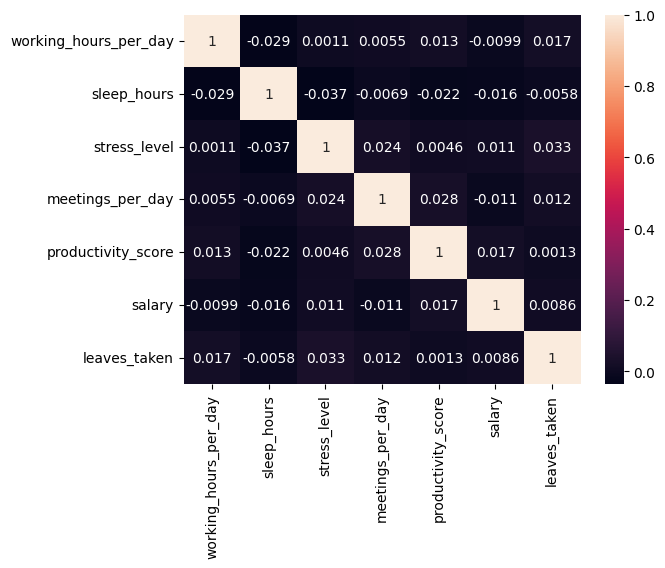

In [65]:
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)

plt.show()

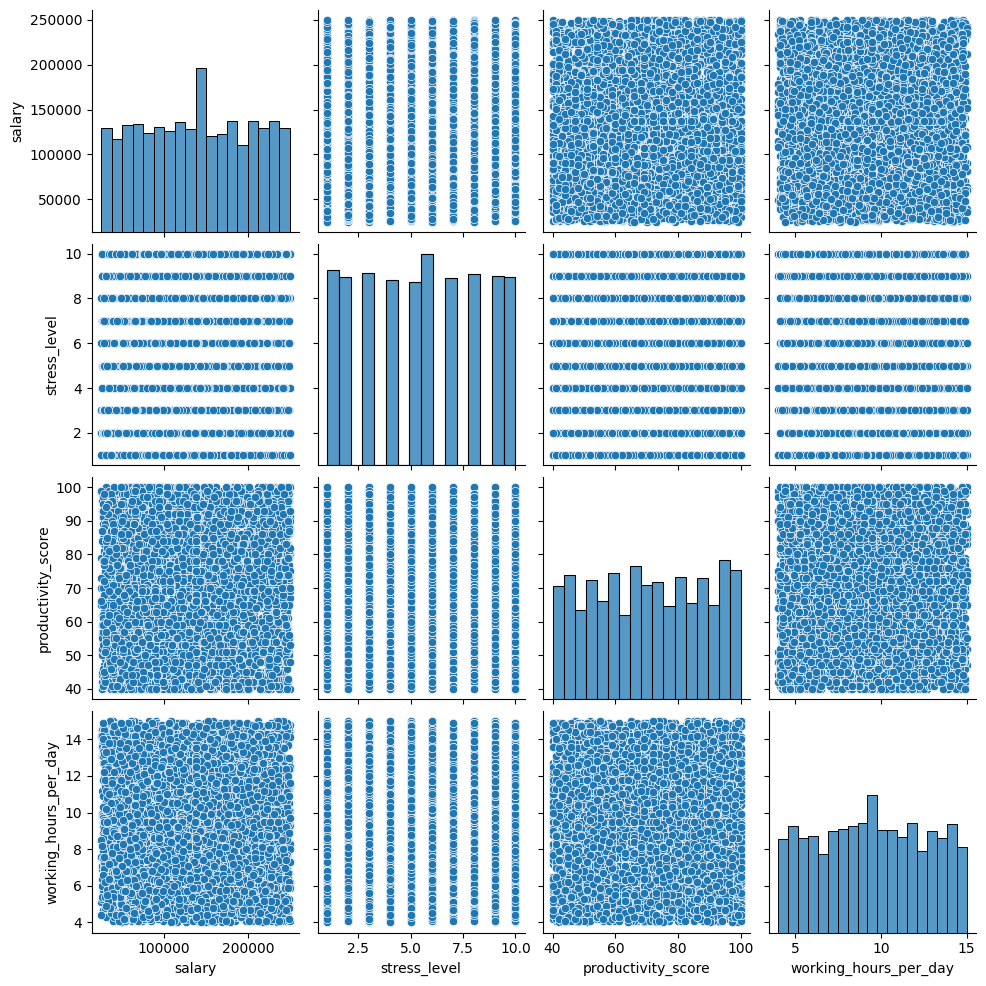

In [66]:
sns.pairplot(df[
    [
        "salary",
        "stress_level",
        "productivity_score",
        "working_hours_per_day"
    ]
])

plt.show()

# Save clean Dataset in Excel And CSV Formate

In [71]:
df.to_excel(
    "cleaned_employee_burnout_dataset.xlsx",
    index=False
)

In [72]:
df.to_csv(
    "cleaned_employee_burnout_dataset.csv",
    index=False
)

# Final Insights

# Problems & Solutions Identified from the Project

---

## 1. High Employee Stress

### Problem
Employees with higher stress levels showed lower productivity and a higher risk of burnout.

### Solution
The company should reduce excessive workload, provide mental wellness support, and improve work-life balance policies.

---

## 2. Long Working Hours

### Problem
Employees working excessive hours were not always more productive and were more likely to experience burnout and fatigue.

### Solution
The company should properly manage working hours, avoid employee overworking, and encourage regular breaks.

---

## 3. Too Many Meetings

### Problem
Employees attending many meetings daily showed reduced focus and lower productivity.

### Solution
The company should reduce unnecessary meetings and improve communication through efficient collaboration tools.

---

## 4. Low Sleep Hours

### Problem
Employees with fewer sleep hours experienced higher stress levels and lower work efficiency.

### Solution
The company should encourage healthy work schedules and promote better work-life balance practices.

---

## 5. High Burnout in Certain Departments

### Problem
Some departments showed significantly higher burnout risk due to heavy workload and work pressure.

### Solution
HR teams should provide additional support, balance employee workload, and hire extra staff where necessary.

---

# Final Conclusion

This project successfully identified employee burnout, stress, and productivity-related issues using Python data analysis and visualization techniques.

By cleaning and analyzing the dataset, meaningful business insights were generated that can help companies:
- improve employee well-being
- reduce burnout risk
- increase productivity
- optimize HR decision-making
- create healthier work environments

This project demonstrates how data analytics can support real-world business and HR decision-making.